In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
class PINN(nn.Module):
    def __init__(self, hidden_units=20, hidden_layers=3, activation='tanh'):
        super(PINN, self).__init__()
        
        # Define activation function
        if activation == 'tanh':
            self.activation = torch.tanh
        elif activation == 'relu':
            self.activation = F.relu
        else:
            raise ValueError(f"Unsupported activation: {activation}")
        
        # Define layers
        self.hidden_layers = nn.ModuleList()
        for _ in range(hidden_layers):
            self.hidden_layers.append(nn.Linear(hidden_units, hidden_units))
        
        self.input_layer = nn.Linear(1, hidden_units)  # Input layer
        self.output_layer = nn.Linear(hidden_units, 1)  # Output layer

    def forward(self, x):
        x = self.input_layer(x)  # Pass through the input layer
        for layer in self.hidden_layers:
            x = self.activation(layer(x))  # Pass through each hidden layer with activation
        x = self.output_layer(x)  # Pass through the output layer
        return x


In [7]:
def loss_I1(model1, model2, x1, f1, I1, overlap, p):
    """
    Loss function for subdomain I1.
    :param model1: First model
    :param model2: Second model
    :param x1: Input tensor for subdomain I1
    :param f1: Forcing function values for subdomain I1
    :param I1: Boundary points for subdomain I1
    :param overlap: Overlapping points between subdomains
    :param p: Regularization parameter
    """
    x1.requires_grad = True

    # Model outputs
    u1 = model1(x1)
    u2 = model2(x1)

    # Gradients with respect to x1
    u1_x = torch.autograd.grad(u1, x1, grad_outputs=torch.ones_like(u1), create_graph=True)[0]
    u1_xx = torch.autograd.grad(u1_x, x1, grad_outputs=torch.ones_like(u1_x), create_graph=True)[0]
    u1_x_overlap = u1_x[-1]

    u2_x_overlap = torch.autograd.grad(u2, x1, grad_outputs=torch.ones_like(u2), create_graph=True)[0][-1]

    # Interior loss
    interior_loss = torch.mean((u1[1:-1] - u1_xx[1:-1] + f1[1:-1]) ** 2)

    # Boundary condition
    bc1 = (model1(torch.tensor([[I1[0]]], dtype=torch.float32)) - 0) ** 2

    # Transmission conditions
    Tc1 = (
        (p * model1(torch.tensor([[overlap[1]]], dtype=torch.float32)) + u1_x_overlap) -
        (p * model2(torch.tensor([[overlap[1]]], dtype=torch.float32)) + u2_x_overlap)
    ) ** 2

    # Total loss
    loss = interior_loss + bc1 + Tc1
    return loss

def loss_I2(model1, model2, x2, f2, I2, overlap, q):
    """
    Loss function for subdomain I2.
    :param model1: First model
    :param model2: Second model
    :param x2: Input tensor for subdomain I2
    :param f2: Forcing function values for subdomain I2
    :param I2: Boundary points for subdomain I2
    :param overlap: Overlapping points between subdomains
    :param q: Regularization parameter
    """
    x2.requires_grad = True

    # Model outputs
    u2 = model2(x2)
    u1 = model1(x2)

    # Gradients with respect to x2
    u2_x = torch.autograd.grad(u2, x2, grad_outputs=torch.ones_like(u2), create_graph=True)[0]
    u2_xx = torch.autograd.grad(u2_x, x2, grad_outputs=torch.ones_like(u2_x), create_graph=True)[0]
    u2_x_overlap = u2_x[0]

    u1_x_overlap = torch.autograd.grad(u1, x2, grad_outputs=torch.ones_like(u1), create_graph=True)[0][0]

    # Interior loss
    interior_loss = torch.mean((u2[1:-1] - u2_xx[1:-1] - f2[1:-1]) ** 2)

    # Boundary condition
    bc2 = (model2(torch.tensor([[I2[1]]], dtype=torch.float32)) - 0) ** 2

    # Transmission conditions
    Tc2 = (
        (q * model2(torch.tensor([[overlap[0]]], dtype=torch.float32)) + u2_x_overlap) -
        (q * model1(torch.tensor([[overlap[0]]], dtype=torch.float32)) + u1_x_overlap)
    ) ** 2

    # Total loss
    loss = interior_loss + bc2 + Tc2
    return loss


In [8]:
# Instantiate models for each subdomain
model1 = PINN(hidden_units=20, hidden_layers=2, activation='tanh')
model2 = PINN(hidden_units=20, hidden_layers=2, activation='tanh')

# Initialize models by passing dummy input
np.random.seed(42)
dummy_input = torch.tensor(np.random.randn(1, 1), dtype=torch.float32)
_ = model1(dummy_input)  # Initialize weights for model1
_ = model2(dummy_input)  # Initialize weights for model2

# Save initial weights
initial_weights_model1 = {name: param.clone() for name, param in model1.named_parameters()}
initial_weights_model2 = {name: param.clone() for name, param in model2.named_parameters()}


In [24]:
deltas = [0.5, 0.3, 0.1, 1e-2, 1e-3]

In [44]:
# Define the domain and subdomains
Iter = []

for h in deltas:
    print(f"For delta = {h}")
    I = [-1, 1]
    I1 = [-1, h]
    I2 = [0, 1]
    overlap = [0, h]  # Overlapping domain
    N1 = 10  # Number of training points in each subdomain
    N2 = 10

    # Generate training points for each subdomain
    x1 = torch.tensor(np.linspace(I1[0], I1[1], N1).reshape(-1, 1), dtype=torch.float32, requires_grad=True)
    x2 = torch.tensor(np.linspace(I2[0], I2[1], N2).reshape(-1, 1), dtype=torch.float32, requires_grad=True)

    # Generate prediction data
    x1_all = torch.tensor(np.linspace(I1[0], I1[1], 200).reshape(-1, 1), dtype=torch.float32)
    x2_all = torch.tensor(np.linspace(I2[0], I2[1], 200).reshape(-1, 1), dtype=torch.float32)

    # Function f1 and f2
    f1 = torch.zeros_like(x1)
    f2 = torch.zeros_like(x2)

    # Reset the models to their initial weights
    model1.load_state_dict(initial_weights_model1)
    model2.load_state_dict(initial_weights_model2)

    # Training loop with while condition
    tol = 1e-5
    losses1 = []
    losses2 = []
    epoch = 0

    # Define optimizers
    optimizer1 = Adam(model1.parameters(), lr=1e-3)
    optimizer2 = Adam(model2.parameters(), lr=1e-3)

    while True:
        # Train model1
        optimizer1.zero_grad()
        loss1 = loss_I1(model1, model2, x1, f1, I1, overlap, 1)
        loss1.backward()
        optimizer1.step()

        # Train model2
        optimizer2.zero_grad()
        loss2 = loss_I2(model1, model2, x2, f2, I2, overlap, 1)
        loss2.backward()
        optimizer2.step()

        losses1.append(loss1.item())
        losses2.append(loss2.item())

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss1: {loss1.item()}, Loss2: {loss2.item()}")

        epoch += 1

        if epoch == 1:
            u1_first_pred = model1(x1_all).detach().numpy()
            u2_first_pred = model2(x2_all).detach().numpy()

        if loss1.item() + loss2.item() < tol:
            Iter.append(epoch)
            print(f"Last Epoch {epoch}, Loss1: {loss1.item()}, Loss2: {loss2.item()}")
            print("\n")
            break


For delta = 0.5
Epoch 0, Loss1: 0.16670529544353485, Loss2: 0.0329236164689064
Epoch 50, Loss1: 0.0002299794286955148, Loss2: 3.8847658288432285e-05
Epoch 100, Loss1: 2.304709232703317e-05, Loss2: 1.5775947758811526e-05
Epoch 150, Loss1: 8.452886504528578e-06, Loss2: 5.788583621324506e-06
Last Epoch 169, Loss1: 6.131062491476769e-06, Loss2: 3.8020091324142413e-06


For delta = 0.3
Epoch 0, Loss1: 0.17305059731006622, Loss2: 0.032923921942710876
Epoch 50, Loss1: 0.0002960922720376402, Loss2: 6.769062019884586e-05
Epoch 100, Loss1: 2.3430411602021195e-05, Loss2: 1.67933994816849e-05
Epoch 150, Loss1: 6.195054083946161e-06, Loss2: 6.382220817613415e-06
Last Epoch 164, Loss1: 5.081235485704383e-06, Loss2: 4.839899247599533e-06


For delta = 0.1
Epoch 0, Loss1: 0.1799091398715973, Loss2: 0.0329304039478302
Epoch 50, Loss1: 0.00038601685082539916, Loss2: 0.00010369693336542696
Epoch 100, Loss1: 2.878017767216079e-05, Loss2: 1.3797861356579233e-05
Epoch 150, Loss1: 5.169056748854928e-06, Loss

In [45]:
Iter

[169, 164, 154, 153, 154]

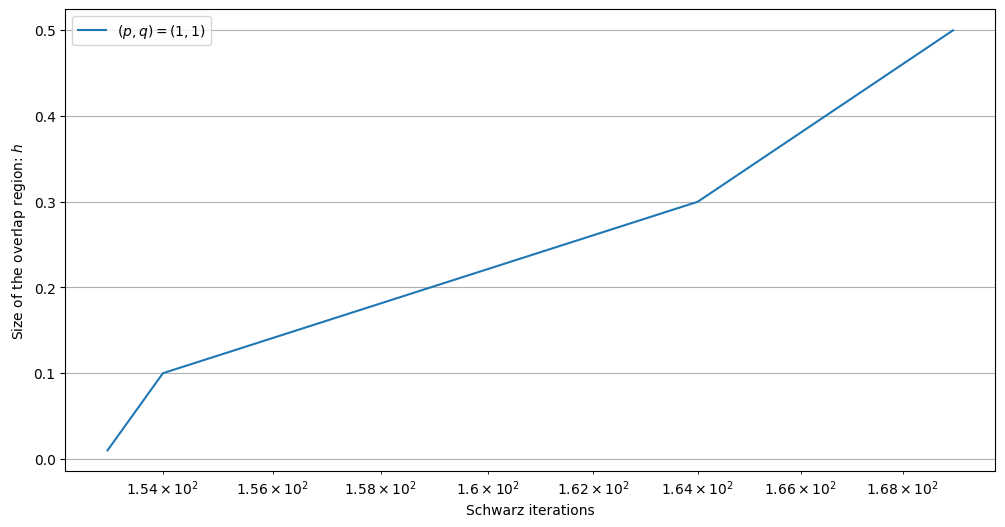

In [54]:
plt.figure( figsize=(12, 6))
plt.plot(Iter[:-1], deltas[:-1], label = "$(p,q) = (1,1)$")
plt.xlabel("Schwarz iterations")
plt.ylabel("Size of the overlap region: $h$")
plt.xscale("log")
#plt.yscale("log")
plt.legend()
plt.grid(True)

# Predictions

> ## --------------Preditions at first iteration---------------


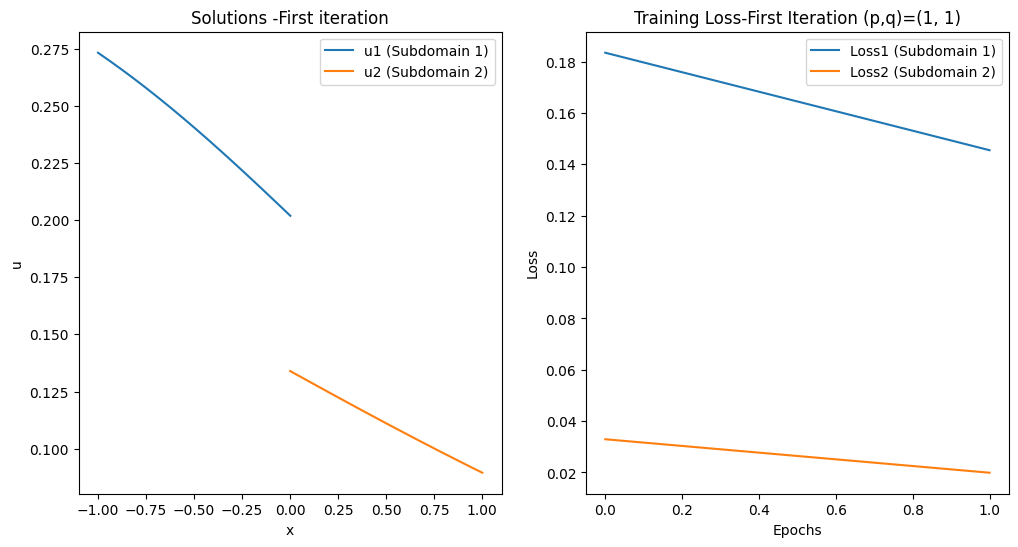

In [56]:
# For video recording
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ims = []

im1, = ax1.plot(x1_all, u1_first_pred, label='u1 (Subdomain 1)')
im2, = ax1.plot(x2_all, u2_first_pred, label='u2 (Subdomain 2)')
ax1.set_xlabel('x')
ax1.set_ylabel('u')
ax1.set_title('Solutions -First iteration')
ax1.legend()

im3, = ax2.plot(losses1[:2], label='Loss1 (Subdomain 1)')
im4, = ax2.plot(losses2[:2], label='Loss2 (Subdomain 2)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss-First Iteration (p,q)=(1, 1)')
ax2.legend()

plt.show()


> ## --------------Preditions at last iteration---------------

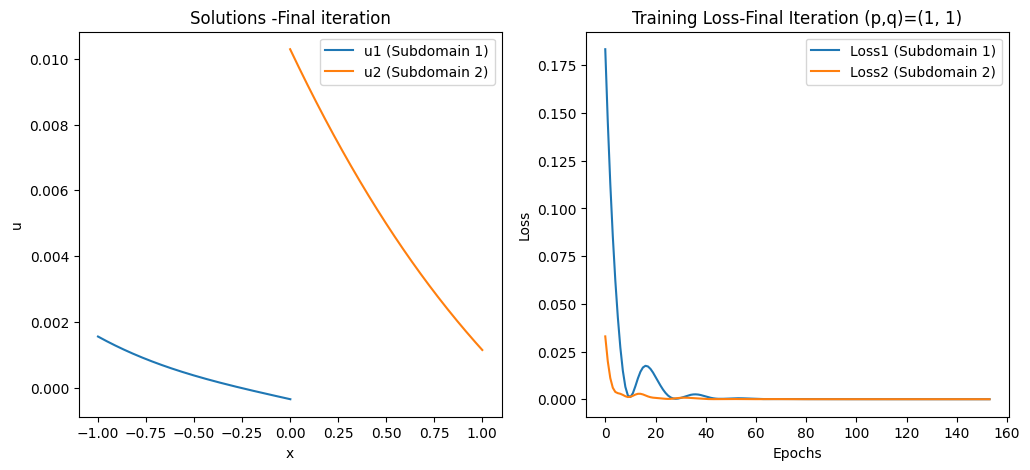

In [55]:
## Last iteration
u1_pred = model1(x1_all).detach().numpy()
u2_pred = model2(x2_all).detach().numpy()

# For video recording
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ims = []

im1, = ax1.plot(x1_all, u1_pred, label='u1 (Subdomain 1)')
im2, = ax1.plot(x2_all, u2_pred, label='u2 (Subdomain 2)')
ax1.set_xlabel('x')
ax1.set_ylabel('u')
ax1.set_title('Solutions -Final iteration')
ax1.legend()

im3, = ax2.plot(losses1, label='Loss1 (Subdomain 1)')
im4, = ax2.plot(losses2, label='Loss2 (Subdomain 2)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss-Final Iteration (p,q)=(1, 1)')
ax2.legend()

#ims.append([im1, im2, im3, im4])

#ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
#ani.save("training_animation.gif", writer=animation.PillowWriter(fps=10))

plt.show()